# Yolo Model Training 1

| Item | Description|
|---|---|
|Model| `yolov11n`|
|Dataset size| 1k images|



---

## Imports

In [1]:
from ultralytics import YOLO
import torch

---

## GPU Check/Troubleshoot

Let's first check if I'm using a GPU.

In [11]:
print(torch.__version__)        # should end in +cu121 or similar
print(torch.cuda.is_available())

2.11.0+cpu
False


Looks like I'm using the CPU version of torchvision, let's change that:

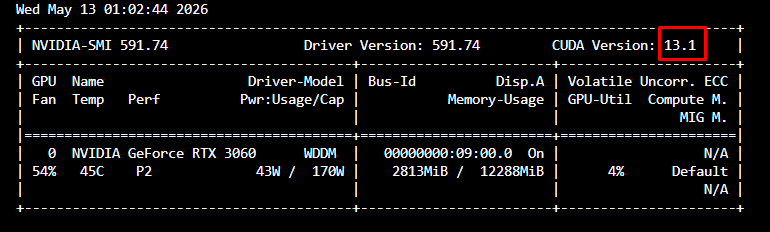

I'm using CUDA v13.1. Let's download it using the pytorch docs website:

<br>
<br>

[Link to pytorch documentation](https://pytorch.org/get-started/locally/)


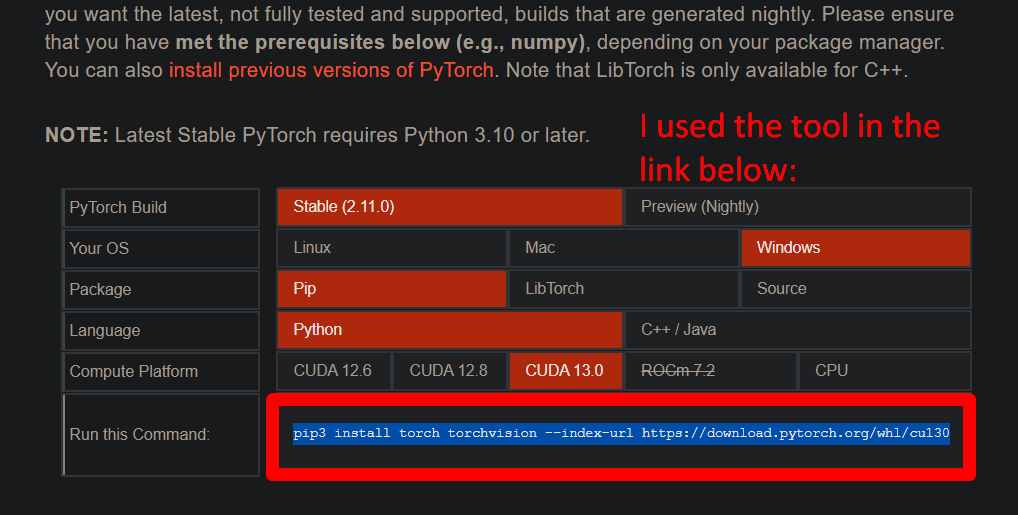

In [2]:
print(torch.__version__)        # should end in +cu121 or similar
print(torch.cuda.is_available())

2.12.0+cu130
True


Now, I'll be using my GPU instead of a CPU, which significantly speeds up training time. 

--- 

## Training

In [ ]:
# Initialize our yolo model as 'model'
model = YOLO("yolo11n.pt")

# Trains the model using the yaml instructions.
train = model.train(
    data=r"C:\Users\kykis\bunnycam\YOLO\datasets\model_1\dataset.yaml",   # path to the yaml file
    epochs=10,                                                            # Amount of batch cycles
    imgsz=640,                                                            # Image size
    device=0                                                              # Use GPU
)

Ultralytics 8.4.49  Python-3.13.13 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3060, 12287MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\kykis\bunnycam\YOLO\datasets\model_1\dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimize

In [5]:
model = YOLO(r"C:\Users\kykis\bunnycam\runs\detect\train\weights\best.pt")
results = model.predict(
    source=r"C:\Users\kykis\bunnycam\YOLO\datasets\test_pictures\set2_device_E8F60A870078_date_11-05-26_hours_22.56.00.jpg",
    conf=0.25,
    device=0
)

results[0].show()


image 1/1 C:\Users\kykis\bunnycam\YOLO\datasets\test_pictures\set2_device_E8F60A870078_date_11-05-26_hours_22.56.00.jpg: 480x640 1 Aune, 9.0ms
Speed: 2.0ms preprocess, 9.0ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)


### Test Prediction 1 -- Easy

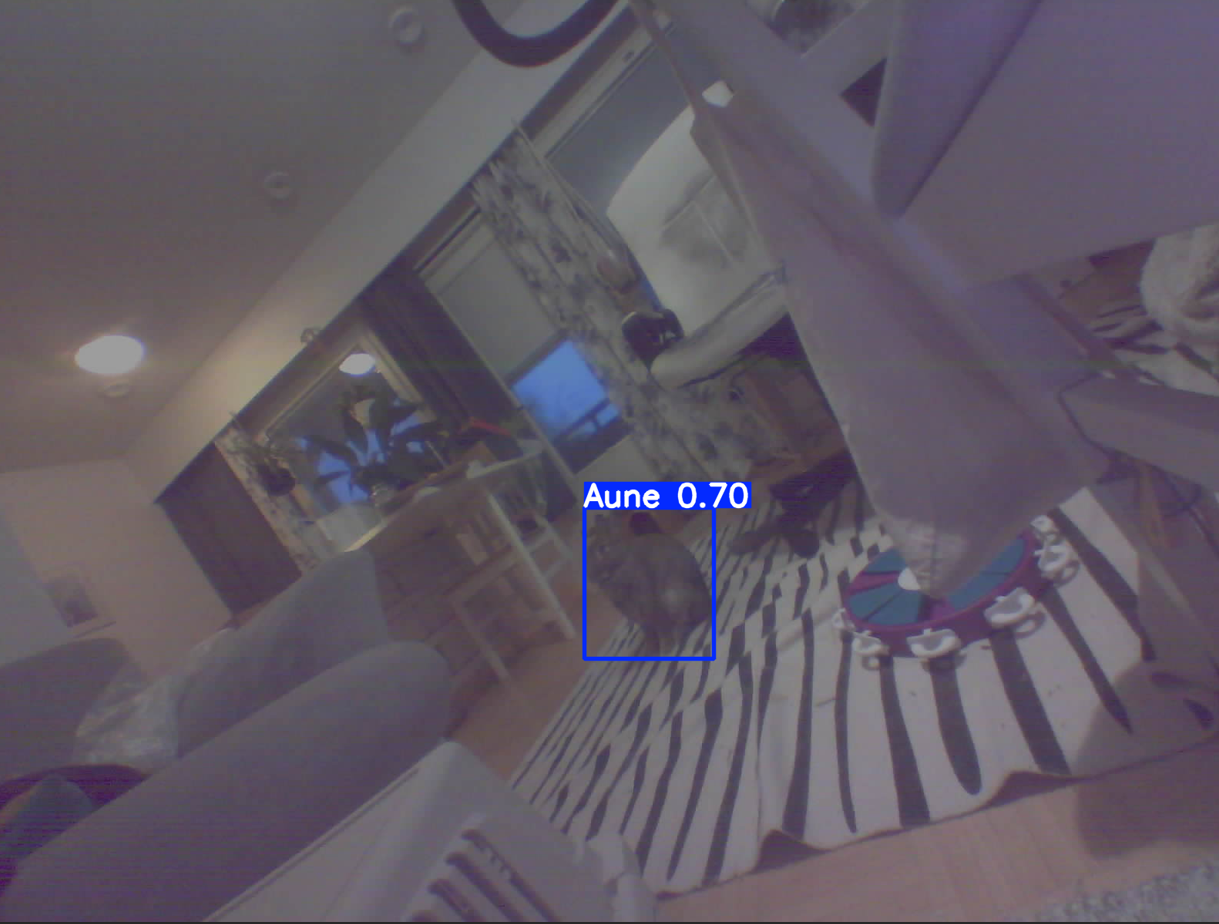

In [7]:
model = YOLO(r"C:\Users\kykis\bunnycam\runs\detect\train\weights\best.pt")
results = model.predict(
    source=r"C:\Users\kykis\bunnycam\YOLO\datasets\test_pictures\set2_device_E8F60A870078_date_11-05-26_hours_22.59.14.jpg",
    conf=0.25,
    device=0
)

results[0].show()


image 1/1 C:\Users\kykis\bunnycam\YOLO\datasets\test_pictures\set2_device_E8F60A870078_date_11-05-26_hours_22.59.14.jpg: 480x640 1 Aune, 9.8ms
Speed: 1.7ms preprocess, 9.8ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)


### Test Prediction 2 -- Intermediate

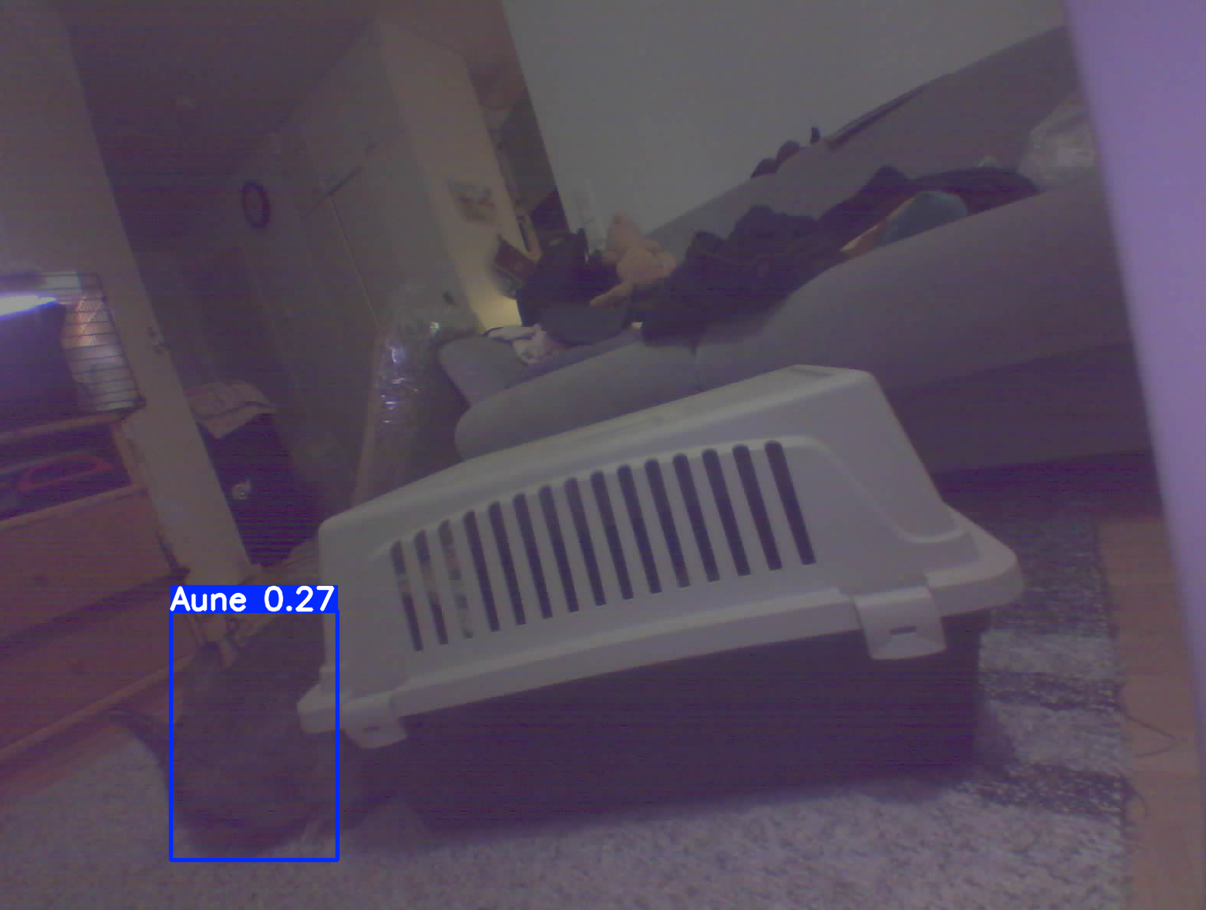

In [8]:
model = YOLO(r"C:\Users\kykis\bunnycam\runs\detect\train\weights\best.pt")
results = model.predict(
    source=r"C:\Users\kykis\bunnycam\YOLO\datasets\test_pictures\set2_device_E8F60A870078_date_11-05-26_hours_23.06.40.jpg",
    conf=0.25,
    device=0
)

results[0].show()


image 1/1 C:\Users\kykis\bunnycam\YOLO\datasets\test_pictures\set2_device_E8F60A870078_date_11-05-26_hours_23.06.40.jpg: 480x640 1 Dippi, 36.3ms
Speed: 4.2ms preprocess, 36.3ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)


### Test Prediction 3 -- Hard

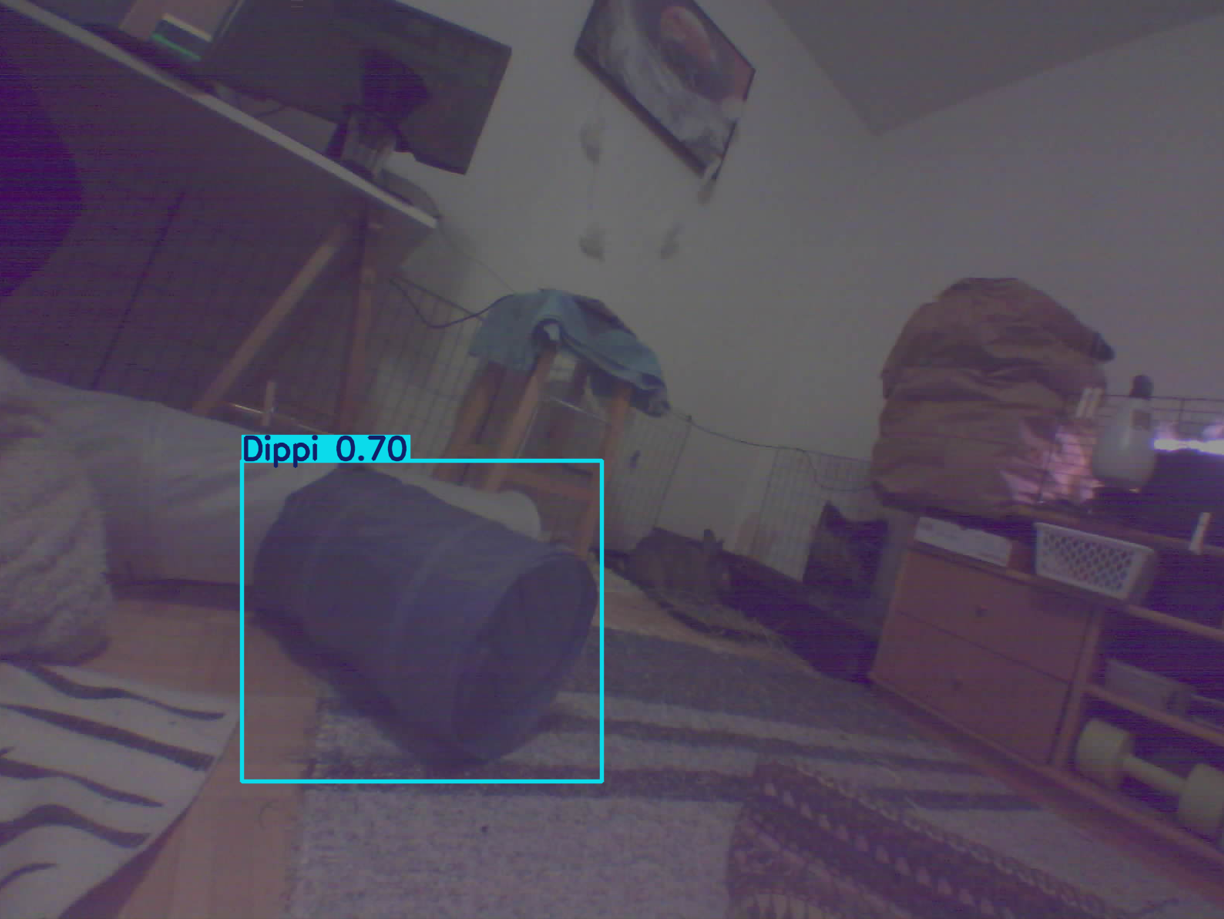

In [10]:
model = YOLO(r"C:\Users\kykis\bunnycam\runs\detect\train\weights\best.pt")
results = model.predict(
    source=r"C:\Users\kykis\bunnycam\YOLO\datasets\test_pictures\set2_device_E8F60A870078_date_13-05-26_hours_01.51.49.jpg",
    conf=0.25,
    device=0
)

results[0].show()


image 1/1 C:\Users\kykis\bunnycam\YOLO\datasets\test_pictures\set2_device_E8F60A870078_date_13-05-26_hours_01.51.49.jpg: 480x640 3 Aunes, 8.9ms
Speed: 2.1ms preprocess, 8.9ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)


### Test Prediction 4 -- Very Hard

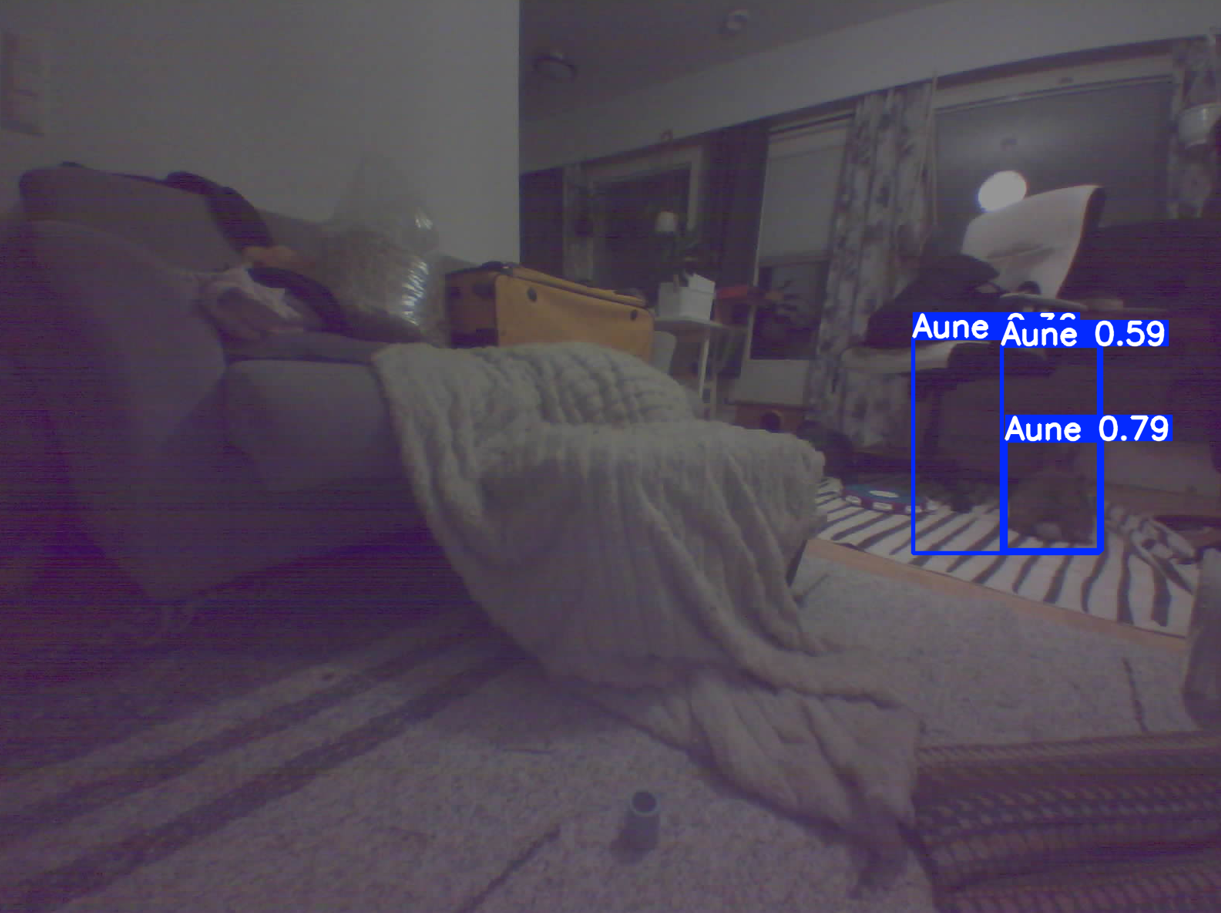